# Environment Setup

## Libraries

In [8]:
# Standard Library
import copy
import os
import random
import shutil
import time
from IPython.display import FileLink
from tqdm import tqdm

# Third-Party Libraries
from collections import Counter
from PIL import Image
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lime import lime_image

# PyTorch / TorchVision
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.quantization
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import torchvision.models as models
from torchvision import datasets, transforms

# Scikit-learn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from skimage.segmentation import mark_boundaries

# Optional UMAP
try:
    import umap.umap_ as umap
    has_umap = True
except ImportError:
    has_umap = False

## Device Selection

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# Dataset Preparation

## Custom Dataset Definition

In [10]:
class TomatoDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        root_dir: path to train or val folder
        transform: torchvision transforms
        """
        self.root_dir = root_dir
        self.transform = transform
        
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        self.samples = []
        
        for cls in self.classes:
            class_path = os.path.join(root_dir, cls)
            for img in os.listdir(class_path):
                img_path = os.path.join(class_path, img)
                self.samples.append((img_path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

## Dataset Split and Dataloaders Instantiation

In [11]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# Load FULL training dataset
full_train_dataset = TomatoDataset(
    root_dir="/kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/train",
    transform=train_transform
)

# Split sizes
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

# Split dataset
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # reproducible split
)

# Test dataset (original val folder)
test_dataset = TomatoDataset(
    root_dir="/kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/val",
    transform=val_transform
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Model Preparation

In [12]:
num_classes = len(train_dataset.dataset.classes)  # number of tomato classes

model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)

# Replace classifier
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 144MB/s]

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

# Training and Validation

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4
)

num_epochs = 100
patience = 5
best_val_loss = float("inf")
early_stop_counter = 0
start_epoch = 0

checkpoint_path = "checkpoint.pth"
best_model_path = "best_model.pth"

train_acc_history = []
val_acc_history = []


Epoch 1/100


Val Loss: 0.5786: 100%|██████████| 32/32 [00:15<00:00,  2.02it/s]


Train Loss: 0.7600
Train Acc: 0.7863
Val Loss: 0.6704
Val Acc: 0.7570
Saving best model...

Epoch 2/100


Val Loss: 0.0965: 100%|██████████| 32/32 [00:06<00:00,  4.75it/s]


Train Loss: 0.1338
Train Acc: 0.9578
Val Loss: 0.1009
Val Acc: 0.9690
Saving best model...

Epoch 3/100


...

Train Loss: 0.0088
Train Acc: 0.9973
Val Loss: 0.0358
Val Acc: 0.9900
Early stopping counter: 3/5

Epoch 12/100


Val Loss: 0.1361: 100%|██████████| 32/32 [00:06<00:00,  4.87it/s]


Train Loss: 0.0077
Train Acc: 0.9976
Val Loss: 0.0328
Val Acc: 0.9890
Early stopping counter: 4/5

Epoch 13/100


Val Loss: 0.1641: 100%|██████████| 32/32 [00:06<00:00,  4.75it/s]


Train Loss: 0.0061
Train Acc: 0.9986
Val Loss: 0.0387
Val Acc: 0.9870
Early stopping counter: 5/5
Early stopping triggered


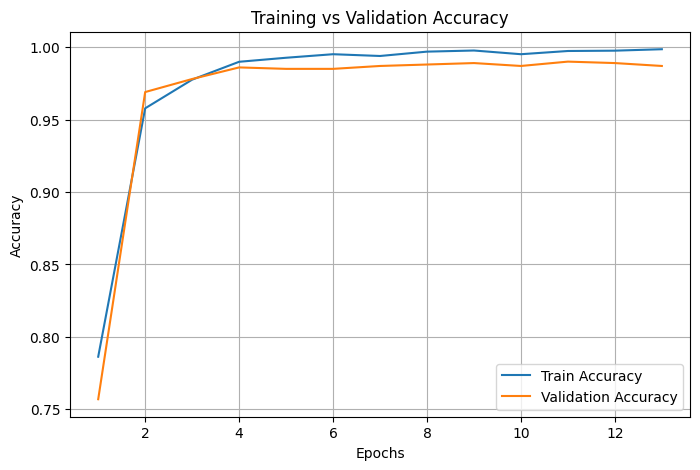

In [14]:
if os.path.exists(checkpoint_path):

    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    early_stop_counter = checkpoint["early_stop_counter"]

    train_acc_history = checkpoint["train_acc_history"]
    val_acc_history = checkpoint["val_acc_history"]

    print(f"Resuming from epoch {start_epoch}")

for epoch in range(start_epoch, num_epochs):

    print(f"\nEpoch {epoch+1}/{num_epochs}")

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    train_bar = tqdm(train_loader)

    for images, labels in train_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        train_bar.set_description(f"Train Loss: {loss.item():.4f}")

    train_loss /= len(train_loader)
    train_acc = correct / total
    
#Validation
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_bar = tqdm(val_loader)

    with torch.no_grad():

        for images, labels in val_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_bar.set_description(f"Val Loss: {loss.item():.4f}")

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc: {train_acc:.4f}")

    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f}")

#save check Point
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
        "early_stop_counter": early_stop_counter,
        "train_acc_history": train_acc_history,
        "val_acc_history": val_acc_history
    }, checkpoint_path)
    
#best Model saving
    if val_loss < best_val_loss:

        print("Saving best model...")

        best_val_loss = val_loss
        early_stop_counter = 0

        torch.save(model.state_dict(), best_model_path)

    else:

        early_stop_counter += 1
        print(f"Early stopping counter: {early_stop_counter}/{patience}")

    if early_stop_counter >= patience:
        print("Early stopping triggered")
        break

epochs = range(1, len(train_acc_history) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_acc_history, label="Train Accuracy")
plt.plot(epochs, val_acc_history, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# Testing and Evaluation

In [15]:
num_classes = len(test_dataset.classes)

model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

model.load_state_dict(torch.load("best_model.pth", map_location=device))

model = model.to(device)
model.eval()

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

100%|██████████| 32/32 [00:14<00:00,  2.16it/s]


                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       1.00      1.00      1.00       100
                        Tomato___Early_blight       0.98      0.98      0.98       100
                         Tomato___Late_blight       0.94      0.99      0.97       100
                           Tomato___Leaf_Mold       1.00      1.00      1.00       100
                  Tomato___Septoria_leaf_spot       0.97      0.98      0.98       100
Tomato___Spider_mites Two-spotted_spider_mite       0.98      0.94      0.96       100
                         Tomato___Target_Spot       0.98      0.94      0.96       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.98      1.00      0.99       100
                 Tomato___Tomato_mosaic_virus       1.00      1.00      1.00       100
                             Tomato___healthy       1.00      1.00      1.00       100

                                     accu

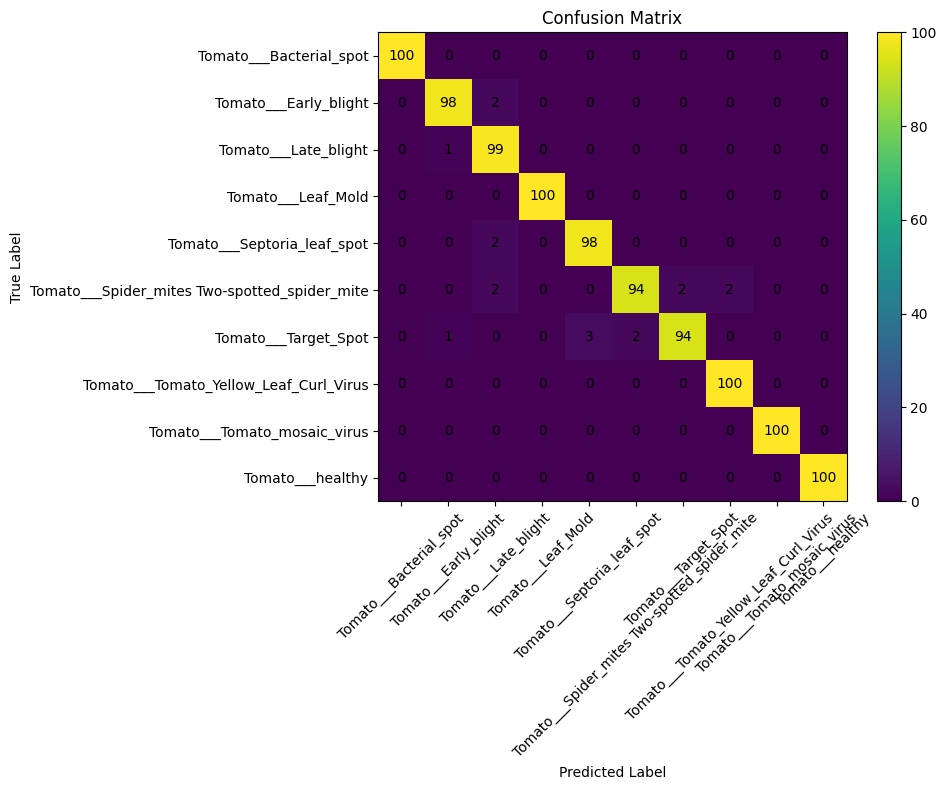

In [16]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = test_dataset.classes

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))

plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")

# write numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.tight_layout()
plt.show()